# Batch LVQ-SOM vs. Standard SOM

This notebook compares three ways to build a prototype-based classifier with DBGSOM:

1. **Majority-vote SOM** (standard approach): train an unsupervised `SomVQ`, then label each prototype with the majority class of its Voronoi set. Prototypes only model the input density — class labels play no role in where they end up.
2. **Batch LVQ-SOM** (`BatchLvqSom`): take the same fitted `SomVQ` and refine its prototypes with the supervised batch LVQ-SOM rule (Kohonen 2001, sec. 6.11). Samples of the "wrong" class *repel* a prototype, samples of its own class attract it — nudging prototypes away from class boundaries.
3. **`SomClassifier`**: the library's supervised SOM (labels assigned during training, but growth and weight updates are still unsupervised).

The LVQ refinement should help exactly where classes overlap: prototypes near a boundary get pushed to the majority side of it.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

from dbgsom import BatchLvqSom, SomClassifier, SomVQ

warnings.filterwarnings("ignore", category=UserWarning)

## Dataset: Overlapping Gaussian Blobs

Five 2-D Gaussian clusters with `cluster_std=3.0` — enough overlap that the Bayes error is clearly nonzero and boundary placement matters.

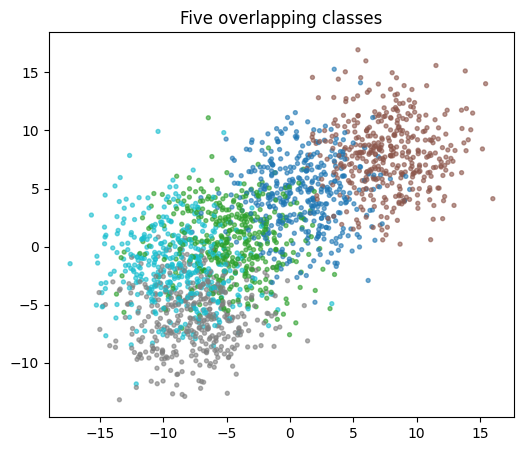

In [2]:
X, y = make_blobs(
    n_samples=2000, centers=5, n_features=2, cluster_std=3.0, random_state=3
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="tab10", s=8, alpha=0.6)
ax.set_title("Five overlapping classes")
plt.show()

## Approach 1: Unsupervised SOM + Majority-Vote Labels

Train `SomVQ` without labels, then assign each prototype the majority class of the training samples it wins.

In [ ]:
som = SomVQ(random_state=42, n_iter=100, max_neurons=60, lambda_=5, verbose=False).fit(
    X_train
)
n_prototypes = som.som_.number_of_nodes()

clusters_train = som.predict(X_train)
majority_label = np.zeros(n_prototypes, dtype=int)
for c in np.unique(clusters_train):
    majority_label[c] = np.bincount(y_train[clusters_train == c]).argmax()

acc_majority = (majority_label[som.predict(X_test)] == y_test).mean()
print(f"prototypes: {n_prototypes}")
print(f"majority-vote accuracy: {acc_majority:.4f}")

prototypes: 26
majority-vote accuracy: 0.6800


## Approach 2: Batch LVQ-SOM Refinement

`BatchLvqSom` takes the fitted `SomVQ` and iterates the signed batch update: each prototype becomes the neighborhood-weighted mean of its samples, where same-class samples count positive and other-class samples negative. Node labels are re-voted each iteration.

In [4]:
lvq = BatchLvqSom(n_iter=10).fit(X_train, y_train, som)
acc_lvq = (lvq.predict(X_test) == y_test).mean()
print(f"Batch LVQ-SOM accuracy: {acc_lvq:.4f}")

Batch LVQ-SOM accuracy: 0.6967


## Approach 3: SomClassifier

The supervised SOM grows its own map on the labelled data. Its prototypes are placed by the same unsupervised update as `SomVQ`, so it matches the majority-vote baseline — labels only enter through prototype labelling, not through weight updates.

In [5]:
clf = SomClassifier(
    random_state=42, n_iter=100, max_neurons=60, lambda_=5, verbose=False
).fit(X_train, y_train)
acc_clf = (clf.predict(X_test) == y_test).mean()
print(f"SomClassifier accuracy: {acc_clf:.4f}")

SomClassifier accuracy: 0.6567


## Decision Boundaries

Where the three approaches place their class boundaries. The LVQ panel should differ from the other two near class borders.

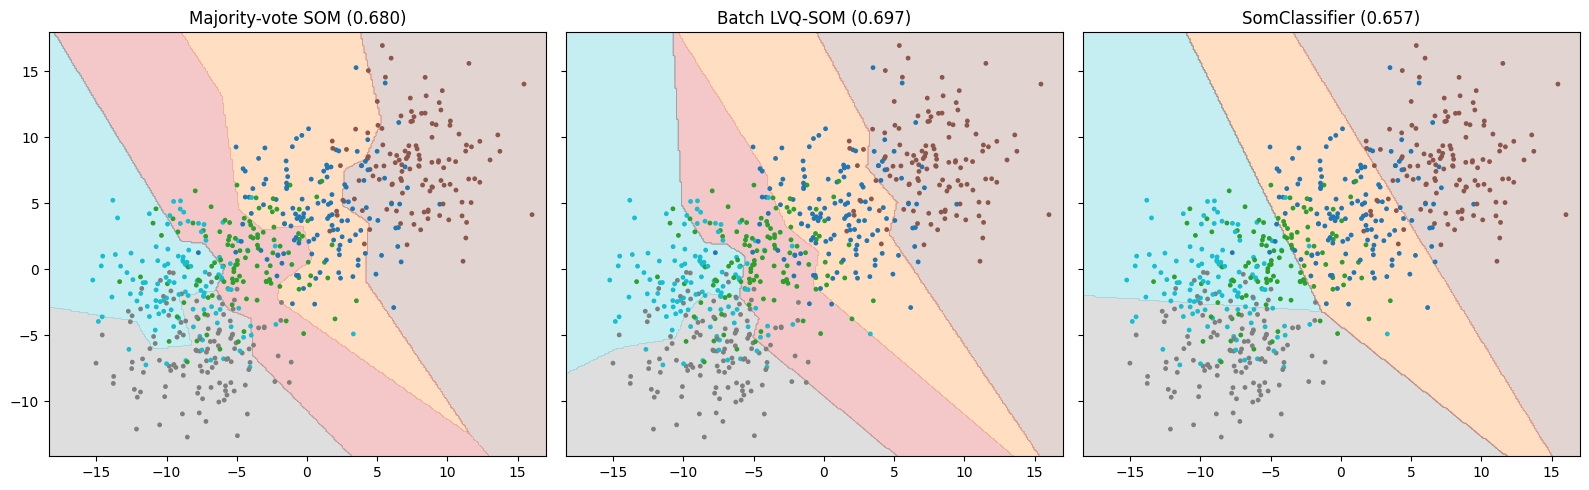

In [6]:
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]

predictions = {
    f"Majority-vote SOM ({acc_majority:.3f})": majority_label[som.predict(grid)],
    f"Batch LVQ-SOM ({acc_lvq:.3f})": lvq.predict(grid),
    f"SomClassifier ({acc_clf:.3f})": clf.predict(grid),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, (title, z) in zip(axes, predictions.items()):
    ax.contourf(xx, yy, z.reshape(xx.shape), cmap="tab10", alpha=0.25, levels=4)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="tab10", s=6)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Prototype Movement

How far the LVQ refinement moved each prototype. Prototypes deep inside a class barely move; prototypes near a boundary get pushed away from the other class. The occasional long jump is a prototype whose signed mean is dominated by repulsion (Kohonen's stability rule skips the update entirely when the signed denominator turns negative).

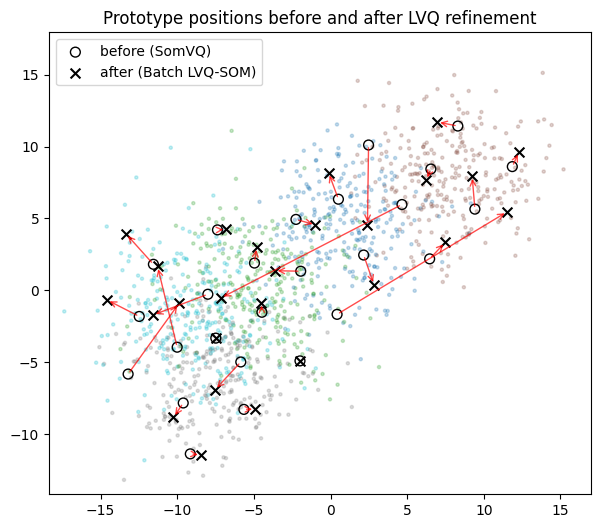

median movement: 1.616
max movement:    13.473


In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="tab10", s=5, alpha=0.25)
ax.scatter(
    som.weights_[:, 0],
    som.weights_[:, 1],
    marker="o",
    s=50,
    facecolors="none",
    edgecolors="black",
    label="before (SomVQ)",
)
ax.scatter(
    lvq.weights_[:, 0],
    lvq.weights_[:, 1],
    marker="x",
    s=50,
    c="black",
    label="after (Batch LVQ-SOM)",
)
for before, after in zip(som.weights_, lvq.weights_):
    ax.annotate(
        "",
        xy=after,
        xytext=before,
        arrowprops=dict(arrowstyle="->", color="red", lw=1, alpha=0.7),
    )
ax.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
ax.set_title("Prototype positions before and after LVQ refinement")
ax.legend()
plt.show()

movement = np.linalg.norm(lvq.weights_ - som.weights_, axis=1)
print(f"median movement: {np.median(movement):.3f}")
print(f"max movement:    {movement.max():.3f}")

## Summary

Same prototypes, same topology — the only difference is the supervised refinement step. Majority-vote SOM and `SomClassifier` place prototypes by density alone and land on the same accuracy; the batch LVQ-SOM update moves boundary prototypes and gains a consistent edge on overlapping classes. The gain is modest here because most of the error is irreducible class overlap, not misplaced boundaries.

Majority-vote SOM    0.6800
SomClassifier        0.6567
Batch LVQ-SOM        0.6967


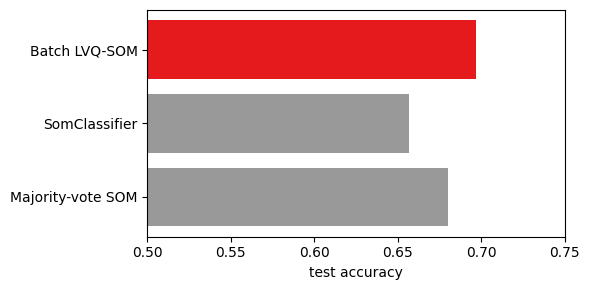

In [8]:
results = {
    "Majority-vote SOM": acc_majority,
    "SomClassifier": acc_clf,
    "Batch LVQ-SOM": acc_lvq,
}
for name, acc in results.items():
    print(f"{name:<20} {acc:.4f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(list(results), list(results.values()), color=["#999", "#999", "#e41a1c"])
ax.set_xlim(0.5, 0.75)
ax.set_xlabel("test accuracy")
plt.tight_layout()
plt.show()